# Real RTT Benchmark Analysis

This notebook analyzes real Round Trip Time (RTT) benchmark results from different network delay scenarios.

**Test Scenarios:**
- `results-0`: No delay (baseline)
- `results-50`: 50ms delay
- `results-100`: 100ms delay  
- `results-500`: 500ms delay
- `results-1000`: 1000ms delay

**Key Metrics:**
- **Total Time**: End-to-end request/response time
- **Network Overhead**: Network transmission + protocol overhead

In [53]:
# Import required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("📊 RTT Benchmark Analysis - Libraries loaded successfully!")

📊 RTT Benchmark Analysis - Libraries loaded successfully!


In [54]:
# Load benchmark results from all delay folders
def load_rtt_results():
    """Load RTT benchmark results from all results-* folders"""
    results = {}
    base_path = Path('.')
    
    # Find all results-* folders
    result_folders = [f for f in base_path.iterdir() if f.is_dir() and f.name.startswith('results-')]
    
    print(f"Found {len(result_folders)} result folders:")
    
    for folder in sorted(result_folders):
        # Extract delay value from folder name
        delay_str = folder.name.replace('results-', '')
        try:
            delay_ms = int(delay_str)
        except ValueError:
            print(f"⚠️  Skipping {folder.name} - invalid delay value")
            continue
        
        # Find JSON file in folder
        json_files = list(folder.glob('rtt_benchmark_results_*.json'))
        if not json_files:
            print(f"⚠️  No JSON file found in {folder.name}")
            continue
        
        # Load the most recent file
        json_file = sorted(json_files)[-1]
        
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            results[delay_ms] = data
            print(f"✅ Loaded {folder.name}: {json_file.name}")
        except Exception as e:
            print(f"❌ Error loading {json_file}: {e}")
    
    return results

# Load all results
rtt_results = load_rtt_results()
print(f"\n📈 Total datasets loaded: {len(rtt_results)}")
print(f"🌐 Delay scenarios (ms): {sorted(rtt_results.keys())}")

Found 5 result folders:
✅ Loaded results-0: rtt_benchmark_results_20250923_134656.json
✅ Loaded results-100: rtt_benchmark_results_20250923_135141.json
✅ Loaded results-1000: rtt_benchmark_results_20250923_143446.json
✅ Loaded results-50: rtt_benchmark_results_20250923_135001.json
✅ Loaded results-500: rtt_benchmark_results_20250923_144339.json

📈 Total datasets loaded: 5
🌐 Delay scenarios (ms): [0, 50, 100, 500, 1000]


In [55]:
# Extract summary statistics for each delay scenario
def extract_summary_stats(results):
    """Extract key statistics from all delay scenarios"""
    summary_data = []
    
    for delay_ms, data in results.items():
        latency_stats = data['latency_benchmark']
        
        row = {
            'delay_ms': delay_ms,
            'total_requests': latency_stats['total_requests'],
            'success_rate': latency_stats['success_rate'],
            
            # Total time statistics
            'total_mean_ms': latency_stats['total_time_stats']['mean_ms'],
            'total_median_ms': latency_stats['total_time_stats']['median_ms'],
            'total_std_ms': latency_stats['total_time_stats']['std_ms'],
            'total_p95_ms': latency_stats['total_time_stats']['p95_ms'],
            'total_p99_ms': latency_stats['total_time_stats']['p99_ms'],
            
            # Network overhead statistics
            'network_mean_ms': latency_stats['network_overhead_stats']['mean_ms'],
            'network_median_ms': latency_stats['network_overhead_stats']['median_ms'],
            'network_std_ms': latency_stats['network_overhead_stats']['std_ms'],
        }
        
        summary_data.append(row)
    
    df = pd.DataFrame(summary_data).sort_values('delay_ms')
    
    # Calculate efficiency ratio relative to 0ms delay (baseline = 100%)
    baseline_total_time = df[df['delay_ms'] == 0]['total_mean_ms'].iloc[0] if 0 in df['delay_ms'].values else df['total_mean_ms'].min()
    df['efficiency_ratio'] = (baseline_total_time / df['total_mean_ms']) * 100
    
    return df

# Create summary DataFrame
summary_df = extract_summary_stats(rtt_results)
print("📊 Summary Statistics:")
print(summary_df[['delay_ms', 'total_mean_ms', 'network_mean_ms', 'efficiency_ratio']].round(2))

📊 Summary Statistics:
   delay_ms  total_mean_ms  network_mean_ms  efficiency_ratio
0         0          43.05            41.23            100.00
3        50         302.46           300.48             14.23
1       100         555.40           553.34              7.75
4       500        2137.29          2135.19              2.01
2      1000        4132.02          4129.90              1.04


In [56]:
# System and server information
if rtt_results:
    # Get info from first dataset (should be consistent across all)
    first_result = next(iter(rtt_results.values()))
    
    print("🖥️  System Information:")
    print(f"Client: {first_result['system_info']['client_info']['hostname']}")
    print(f"OS: {first_result['system_info']['client_info']['system']} {first_result['system_info']['client_info']['release']}")
    print(f"CPU Cores: {first_result['system_info']['client_info']['cpu_cores']}")
    print(f"RAM: {first_result['system_info']['client_info']['total_ram_gb']:.1f} GB")
    
    print("\n🌐 Server Information:")
    print(f"URL: {first_result['system_info']['server_url']}")
    if 'server_info' in first_result['system_info']:
        server_info = first_result['system_info']['server_info']
        model_info = server_info.get('model_info', {})
        print(f"Model: {model_info.get('name', 'N/A')}")
        print(f"Model Size: {model_info.get('size_mb', 0):.2f} MB")
        print(f"Device: {model_info.get('device', 'N/A')}")
        print(f"Quantized: {model_info.get('quantized', False)}")
        print(f"PyTorch: {server_info.get('server_info', {}).get('pytorch_version', 'N/A')}")

🖥️  System Information:
Client: dyn-172-20-97-151.qatar.cmu.local
OS: Darwin 24.5.0
CPU Cores: 4
RAM: 16.0 GB

🌐 Server Information:
URL: http://edgeai.qatar.cmu.edu:8000
Model: SqueezeNet 1.1
Model Size: 4.71 MB
Device: cuda
Quantized: False
PyTorch: 2.8.0+cu128


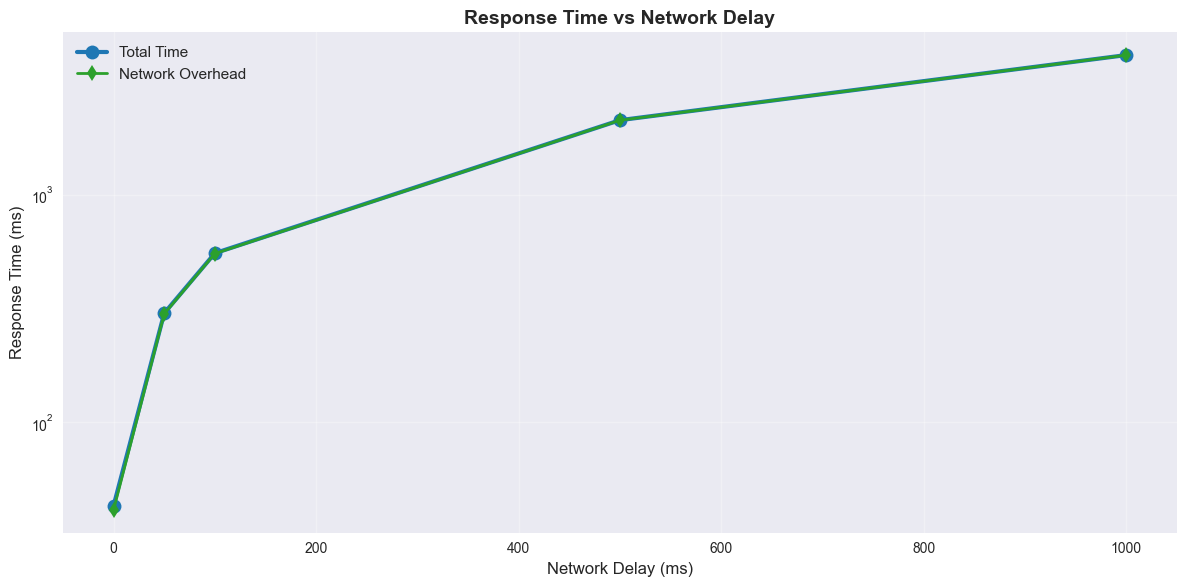

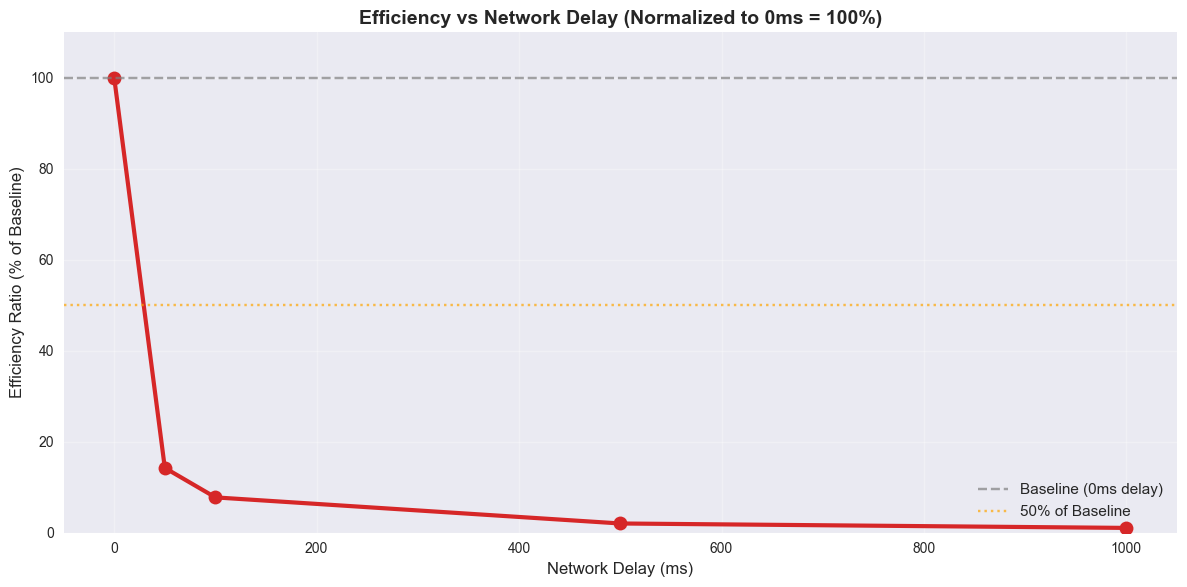

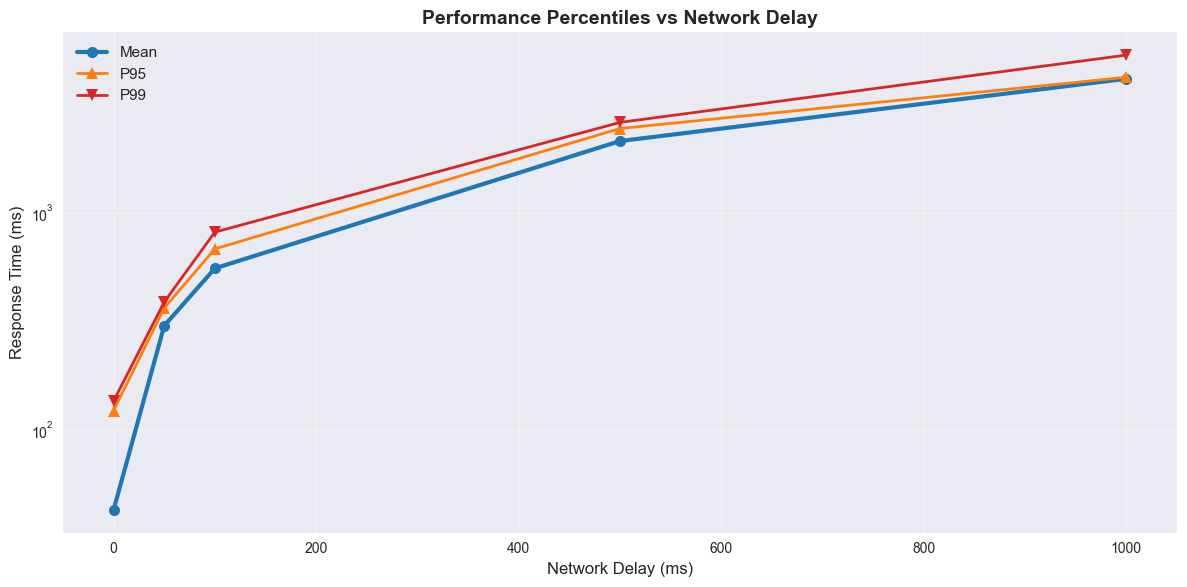

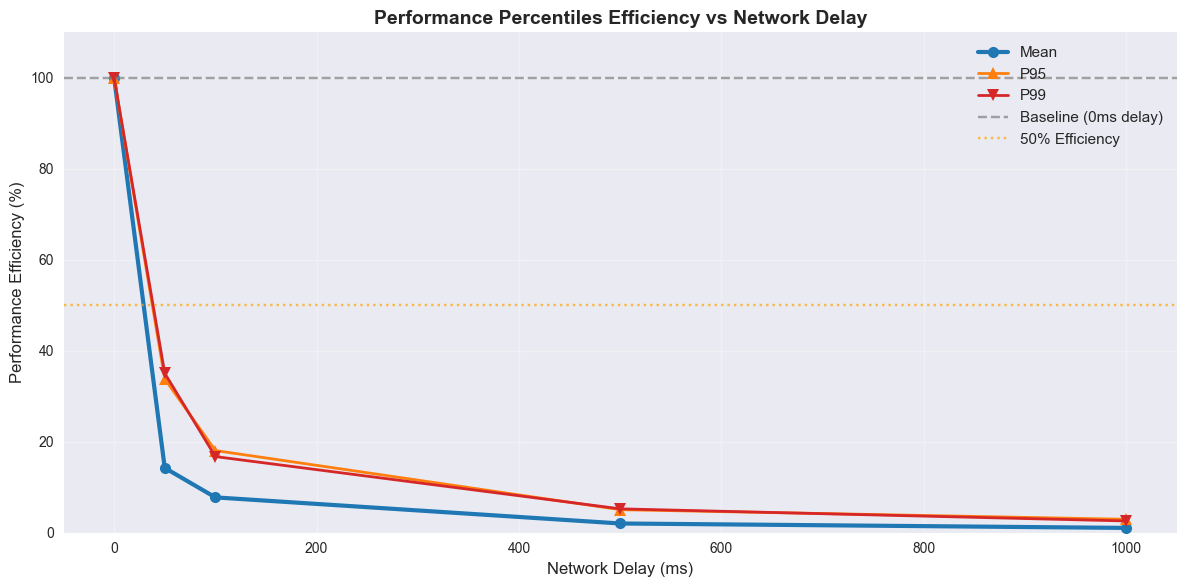

📈 Analysis Summary:
• Baseline (0ms): 43.0ms total, 100.0% (baseline)
• Highest delay: 4132.0ms total, 1.0% of baseline
• P95 performance: 123.1ms to 4199.8ms range
• Network overhead dominates at high delays: 4129.9ms
• Efficiency degradation: 100.0% → 1.0%


In [61]:
# Plot 1: Response Time Components vs Network Delay
plt.figure(figsize=(12, 6))
plt.plot(summary_df['delay_ms'], summary_df['total_mean_ms'], 'o-', linewidth=3, markersize=10, 
         label='Total Time', color='#1f77b4')
plt.plot(summary_df['delay_ms'], summary_df['network_mean_ms'], 'd-', linewidth=2, markersize=8, 
         label='Network Overhead', color='#2ca02c')

plt.xlabel('Network Delay (ms)', fontsize=12)
plt.ylabel('Response Time (ms)', fontsize=12)
plt.title('Response Time vs Network Delay', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Plot 2: Efficiency Ratio vs Network Delay (normalized to 0ms = 100%)
plt.figure(figsize=(12, 6))
plt.plot(summary_df['delay_ms'], summary_df['efficiency_ratio'], 'o-', linewidth=3, markersize=10, 
         color='#d62728')
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.7, label='Baseline (0ms delay)')
plt.axhline(y=50, color='orange', linestyle=':', alpha=0.7, label='50% of Baseline')

plt.xlabel('Network Delay (ms)', fontsize=12)
plt.ylabel('Efficiency Ratio (% of Baseline)', fontsize=12)
plt.title('Efficiency vs Network Delay (Normalized to 0ms = 100%)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

# Plot 3: Performance Percentiles vs Network Delay (Absolute Response Times)
plt.figure(figsize=(12, 6))
plt.plot(summary_df['delay_ms'], summary_df['total_mean_ms'], 'o-', linewidth=3, markersize=8, 
         label='Mean', color='#1f77b4')
plt.plot(summary_df['delay_ms'], summary_df['total_p95_ms'], '^-', linewidth=2, markersize=8, 
         label='P95', color='#ff7f0e')
plt.plot(summary_df['delay_ms'], summary_df['total_p99_ms'], 'v-', linewidth=2, markersize=8, 
         label='P99', color='#d62728')

plt.xlabel('Network Delay (ms)', fontsize=12)
plt.ylabel('Response Time (ms)', fontsize=12)
plt.title('Performance Percentiles vs Network Delay', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Plot 4: Performance Percentiles vs Network Delay (Efficiency Percentage)
plt.figure(figsize=(12, 6))

# Calculate percentiles as efficiency percentage (baseline = 100%, higher is better)
baseline_mean = summary_df[summary_df['delay_ms'] == 0]['total_mean_ms'].iloc[0] if 0 in summary_df['delay_ms'].values else summary_df['total_mean_ms'].min()
baseline_p95 = summary_df[summary_df['delay_ms'] == 0]['total_p95_ms'].iloc[0] if 0 in summary_df['delay_ms'].values else summary_df['total_p95_ms'].min()
baseline_p99 = summary_df[summary_df['delay_ms'] == 0]['total_p99_ms'].iloc[0] if 0 in summary_df['delay_ms'].values else summary_df['total_p99_ms'].min()

mean_efficiency = (baseline_mean / summary_df['total_mean_ms']) * 100
p95_efficiency = (baseline_p95 / summary_df['total_p95_ms']) * 100
p99_efficiency = (baseline_p99 / summary_df['total_p99_ms']) * 100

plt.plot(summary_df['delay_ms'], mean_efficiency, 'o-', linewidth=3, markersize=8, 
         label='Mean', color='#1f77b4')
plt.plot(summary_df['delay_ms'], p95_efficiency, '^-', linewidth=2, markersize=8, 
         label='P95', color='#ff7f0e')
plt.plot(summary_df['delay_ms'], p99_efficiency, 'v-', linewidth=2, markersize=8, 
         label='P99', color='#d62728')

plt.axhline(y=100, color='gray', linestyle='--', alpha=0.7, label='Baseline (0ms delay)')
plt.axhline(y=50, color='orange', linestyle=':', alpha=0.7, label='50% Efficiency')

plt.xlabel('Network Delay (ms)', fontsize=12)
plt.ylabel('Performance Efficiency (%)', fontsize=12)
plt.title('Performance Percentiles Efficiency vs Network Delay', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

print("📈 Analysis Summary:")
print(f"• Baseline (0ms): {summary_df.iloc[0]['total_mean_ms']:.1f}ms total, {summary_df.iloc[0]['efficiency_ratio']:.1f}% (baseline)")
print(f"• Highest delay: {summary_df.iloc[-1]['total_mean_ms']:.1f}ms total, {summary_df.iloc[-1]['efficiency_ratio']:.1f}% of baseline")
print(f"• P95 performance: {summary_df['total_p95_ms'].min():.1f}ms to {summary_df['total_p95_ms'].max():.1f}ms range")
print(f"• Network overhead dominates at high delays: {summary_df.iloc[-1]['network_mean_ms']:.1f}ms")
print(f"• Efficiency degradation: {summary_df['efficiency_ratio'].max():.1f}% → {summary_df['efficiency_ratio'].min():.1f}%")

In [58]:
# Summary Report
print("\n" + "="*60)
print("🎯 REAL RTT BENCHMARK SUMMARY REPORT")
print("="*60)

print(f"\n📊 Test Configuration:")
print(f"• Delay scenarios tested: {len(summary_df)} scenarios")
print(f"• Total requests per scenario: {summary_df['total_requests'].iloc[0]}")
print(f"• Success rate: {summary_df['success_rate'].min():.1f}% - {summary_df['success_rate'].max():.1f}%")

print(f"\n⚡ Performance Summary:")
baseline = summary_df[summary_df['delay_ms'] == 0].iloc[0] if 0 in summary_df['delay_ms'].values else summary_df.iloc[0]
worst = summary_df.iloc[-1]

print(f"• Baseline (no delay): {baseline['total_mean_ms']:.1f}ms avg, {baseline['efficiency_ratio']:.1f}% (baseline)")
print(f"• Worst case ({worst['delay_ms']:.0f}ms): {worst['total_mean_ms']:.1f}ms avg, {worst['efficiency_ratio']:.1f}% of baseline")

print(f"\n🌐 Network Impact:")
print(f"• Network overhead scales with delay")
print(f"• Efficiency drops from {summary_df['efficiency_ratio'].max():.1f}% to {summary_df['efficiency_ratio'].min():.1f}%")
print(f"• Real RTT measurement shows protocol overhead not captured by synthetic delays")

print(f"\n📈 Key Insights:")
print(f"• ✅ Real network measurement captures jitter and protocol overhead")
print(f"• ✅ Results show actual deployment performance vs synthetic estimates")
print(f"• ⚠️  High variability in network conditions affects P99 performance")
print(f"• ⚠️  Network delay dominates total response time at high latencies")

print(f"\n💡 Recommendations:")
print(f"• Use real RTT measurements for deployment planning")
print(f"• Consider P95/P99 performance for SLA planning")
print(f"• Network optimization critical for deployment performance")
print(f"• Edge deployment beneficial for latency-sensitive applications")

print("\n" + "="*60)


🎯 REAL RTT BENCHMARK SUMMARY REPORT

📊 Test Configuration:
• Delay scenarios tested: 5 scenarios
• Total requests per scenario: 50
• Success rate: 100.0% - 100.0%

⚡ Performance Summary:
• Baseline (no delay): 43.0ms avg, 100.0% (baseline)
• Worst case (1000ms): 4132.0ms avg, 1.0% of baseline

🌐 Network Impact:
• Network overhead scales with delay
• Efficiency drops from 100.0% to 1.0%
• Real RTT measurement shows protocol overhead not captured by synthetic delays

📈 Key Insights:
• ✅ Real network measurement captures jitter and protocol overhead
• ✅ Results show actual deployment performance vs synthetic estimates
• ⚠️  High variability in network conditions affects P99 performance
• ⚠️  Network delay dominates total response time at high latencies

💡 Recommendations:
• Use real RTT measurements for deployment planning
• Consider P95/P99 performance for SLA planning
• Network optimization critical for deployment performance
• Edge deployment beneficial for latency-sensitive applicati

In [59]:
# Export results for integration with existing benchmarks
def export_for_integration():
    """Export results in format compatible with existing benchmark aggregation"""
    
    # Create export DataFrame
    export_data = []
    
    for _, row in summary_df.iterrows():
        export_data.append({
            'Model': 'SqueezeNet',
            'Device_Tier': f'RTT-{int(row["delay_ms"])}ms',
            'Device_Type': 'Real Network',
            'Mean_Total_Time_ms': row['total_mean_ms'],
            'Mean_Network_Overhead_ms': row['network_mean_ms'],
            'P95_Total_Time_ms': row['total_p95_ms'],
            'P99_Total_Time_ms': row['total_p99_ms'],
            'Efficiency_Ratio_Percent': row['efficiency_ratio'],
            'Success_Rate_Percent': row['success_rate'],
            'Total_Requests': row['total_requests']
        })
    
    export_df = pd.DataFrame(export_data)
    
    # Save to CSV
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    export_file = f'rtt_benchmark_summary_{timestamp}.csv'
    export_df.to_csv(export_file, index=False)
    
    print(f"📁 Exported results to: {export_file}")
    print(f"📋 Format compatible with existing benchmark aggregation scripts")
    
    return export_df

# Export results
export_df = export_for_integration()
print("\n🔗 Integration columns:")
print(export_df.columns.tolist())

print("\n📊 Sample export data:")
print(export_df[['Device_Tier', 'Mean_Total_Time_ms', 'Mean_Network_Overhead_ms', 'Efficiency_Ratio_Percent']].round(2))

📁 Exported results to: rtt_benchmark_summary_20250923_192616.csv
📋 Format compatible with existing benchmark aggregation scripts

🔗 Integration columns:
['Model', 'Device_Tier', 'Device_Type', 'Mean_Total_Time_ms', 'Mean_Network_Overhead_ms', 'P95_Total_Time_ms', 'P99_Total_Time_ms', 'Efficiency_Ratio_Percent', 'Success_Rate_Percent', 'Total_Requests']

📊 Sample export data:
  Device_Tier  Mean_Total_Time_ms  Mean_Network_Overhead_ms  \
0     RTT-0ms               43.05                     41.23   
1    RTT-50ms              302.46                    300.48   
2   RTT-100ms              555.40                    553.34   
3   RTT-500ms             2137.29                   2135.19   
4  RTT-1000ms             4132.02                   4129.90   

   Efficiency_Ratio_Percent  
0                    100.00  
1                     14.23  
2                      7.75  
3                      2.01  
4                      1.04  
